We aim to classify images of various fish species using a basic DNN model. The task involves processing image data as input, applying appropriate preprocessing steps, and developing a model to accurately predict the fish species from the images.

1. **Data Collection and Validation:**   
   The dataset used contains images of 9 different fish species. Dataset includes: gilt head bream, red sea bream, sea bass, red mullet, horse mackerel, black sea sprat, striped red mullet, trout, shrimp image samples. The images are resized to 590 x 445 pixels.   

2. **Exploratory Data Analysis and Visualization:**
   Before preprocessing, the image dimensions and color channels were analyzed, and necessary visualizations were created.

3. **Image Preprocessing:**
   Image data must be preprocessed before feeding it into the DNN.    
   TO DO: Apply the right image preprocessing 

In [73]:
import gc
import tensorflow as tf

# GPU memory growth — prevents TF from grabbing all VRAM at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU ready: {gpus[0].name}')
else:
    print('No GPU found, running on CPU')


No GPU found, running on CPU


In [74]:
print("TensorFlow version:", tf.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TensorFlow version: 2.4.1
GPU is NOT AVAILABLE


In [75]:
import os
import random
import shutil
import glob
import logging
from tqdm import tqdm
from itertools import compress
from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from PIL import Image
import cv2 as cv
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Flatten,
    LeakyReLU, ReLU, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
plt.style.use('ggplot')
sns.set_palette(sns.diverging_palette(220, 20))
print('Imports OK')


Imports OK


## 1. Data Collection:

In [76]:
fish_dataset_directory = "/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset"
print('Dataset path:', fish_dataset_directory)
print('Exists:', os.path.exists(fish_dataset_directory))


Dataset path: /kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset
Exists: True


In [77]:
def find_image_classes(images_path: str) -> List[str]:
    """
    Find subdirectory names in the specified directory.

    Parameters
    ----------
    images_path : str
        Path to the directory containing subdirectories.

    Returns
    -------
    List[str]
        A list of subdirectory names found within the specified directory.
    """
    return [i for i in os.listdir(images_path) if os.path.isdir(os.path.join(images_path, i))]

In [78]:
image_classes = find_image_classes(fish_dataset_directory)
image_classes

['Hourse Mackerel',
 'Black Sea Sprat',
 'Sea Bass',
 'Red Mullet',
 'Trout',
 'Striped Red Mullet',
 'Shrimp',
 'Gilt-Head Bream',
 'Red Sea Bream']

In [79]:
def df_from_image_folders(images_path: str, extension: Optional[str] = "png") -> pd.DataFrame:
    """
    Create a DataFrame from image files in specified directories.

    Parameters
    ----------
    images_path : str
        Path to the directory containing subdirectories of images.
    extension : str, optional
        The file extension of the images to include (default is "png").

    Returns
    -------
    pd.DataFrame
        A DataFrame with two columns: 'path' containing file paths and 'label' containing the class labels.

    Notes
    -----
    Excludes directories that contain 'GT' in their names.
    """
    
    label = []
    path = []
    image_files = glob.glob(os.path.join(images_path, "**", f"*.{extension.lower()}"), recursive=True)

    for file in image_files:
        dirpath = os.path.dirname(file)
        folder_name = os.path.basename(dirpath)
        label.append(folder_name)
        path.append(file)

    class_dict = {"path": path, "label": label}
    return pd.DataFrame(class_dict)

In [80]:
df = df_from_image_folders(fish_dataset_directory)
# Remove GT (ground-truth mask) folders — keep only fish-image folders
df = df[~df['label'].str.contains('GT', case=False)].reset_index(drop=True)
print(df.shape)
df.head()


(9000, 2)


,path,label
0,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Hourse Mackerel/Hourse Mackerel/00929.png,Hourse Mackerel
1,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Hourse Mackerel/Hourse Mackerel/00704.png,Hourse Mackerel
2,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Hourse Mackerel/Hourse Mackerel/00562.png,Hourse Mackerel
3,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Hourse Mackerel/Hourse Mackerel/00237.png,Hourse Mackerel
4,/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset/Hourse Mackerel/Hourse Mackerel/00406.png,Hourse Mackerel


In [81]:
def display_fish_from_each_class(df: pd.DataFrame, img_size: Tuple[int, int] = (224, 224)) -> None:
    """
    Displays one image from each unique class in the DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing image paths and labels.
    img_size : Tuple[int, int]
        Size to which images will be resized for display.
    """
    
    plt.figure(figsize=(12, 12))
    
    for i, unique_label in enumerate(df["label"].unique()):
        
        plt.subplot(3, 3, i + 1)
        image_path = df[df["label"] == unique_label].iloc[0, 0]
        img = load_img(image_path, target_size=img_size)
        plt.imshow(img)
        plt.title(unique_label)
        plt.axis('off')

    plt.show()

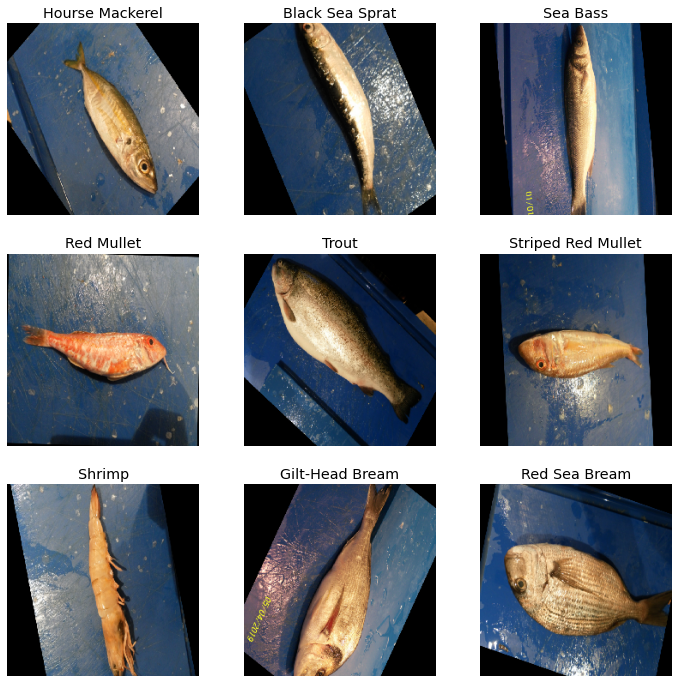

In [82]:
display_fish_from_each_class(df)

In [83]:
def display_images_from_class(df: pd.DataFrame, class_name: str, num_images: int, img_size: Tuple[int, int] = (224, 224)) -> None:
    """
    Displays a specified number of images from a given class in the DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing image paths and labels.
    class_name : str
        The class label to filter the images.
    img_size : Tuple[int, int]
        Size to which images will be resized for display.
    num_images : int
        Number of images to display from the given class.
    """
    images = df[df["label"] == class_name]["path"].iloc[:num_images]
    plt.figure(figsize=(12, 12))

    for i, image_path in enumerate(images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(load_img(image_path, target_size=img_size))
        plt.title(image_path[-5:-4]) 
        plt.axis('off')

    plt.show()

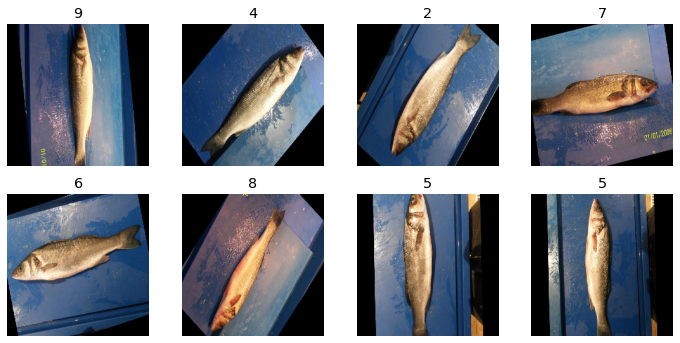

In [84]:
display_images_from_class(df, "Sea Bass", 8)

In [85]:
df["label"].nunique()

9

In [86]:
df[["label"]].value_counts()

label             
Black Sea Sprat       1000
Gilt-Head Bream       1000
Hourse Mackerel       1000
Red Mullet            1000
Red Sea Bream         1000
Sea Bass              1000
Shrimp                1000
Striped Red Mullet    1000
Trout                 1000
dtype: int64

## 2. Exploratory Data Analysis and Visualization:

### 2.1. Analysis of Image Sizes and Channels:

- The purpose of this study is to standardize images if they are different sizes. Using the created function below, it has been determined that all images have the same standard size.

In [87]:
def compute_image_statistics_from_df(df: pd.DataFrame, sample_size: int = 10) -> pd.DataFrame:
    """Sample-based version — doesn't load all images into RAM."""
    stats = []
    for label in df["label"].unique():
        class_df = df[df["label"] == label].sample(min(sample_size, len(df[df["label"] == label])))
        widths, heights, channels = [], [], []
        for path in class_df["path"]:
            with Image.open(path) as img:
                w, h = img.size
                c = len(img.getbands())
            widths.append(w)
            heights.append(h)
            channels.append(c)
        stats.append({
            "Fish Class": label,
            "Average Width": np.mean(widths),
            "Average Height": np.mean(heights),
            "Average Channels": np.mean(channels),
            "Min Width": min(widths), "Max Width": max(widths),
            "Min Height": min(heights), "Max Height": max(heights),
        })
    return pd.DataFrame(stats)


In [88]:
df_statistics = compute_image_statistics_from_df(df)
df_statistics

,Fish Class,Average Width,Average Height,Average Channels,Min Width,Max Width,Min Height,Max Height
0,Hourse Mackerel,590.0,445.0,3.0,590,590,445,445
1,Black Sea Sprat,590.0,445.0,3.0,590,590,445,445
2,Sea Bass,590.0,445.0,3.0,590,590,445,445
3,Red Mullet,590.0,445.0,3.0,590,590,445,445
4,Trout,590.0,445.0,3.0,590,590,445,445
5,Striped Red Mullet,590.0,445.0,3.0,590,590,445,445
6,Shrimp,590.0,445.0,3.0,590,590,445,445
7,Gilt-Head Bream,590.0,445.0,3.0,590,590,445,445
8,Red Sea Bream,590.0,445.0,3.0,590,590,445,445


In [89]:
gc.collect()


43670

### 2.2. Visualization of the image rgb channels

In [90]:
def display_rgb_channels(image_path: str) -> None:
    """
    Displays the individual RGB channels of an image.

    Parameters
    ----------
    image_path : str
        The file path to the image.

    Returns
    -------
    None
    """
    image = Image.open(image_path)
    
    r, g, b = image.split()
    
    r_array = np.array(r)
    g_array = np.array(g)
    b_array = np.array(b)

    fig, axes = plt.subplots(1, 3, figsize=(12,12))

    axes[0].imshow(r_array, cmap="Reds")
    axes[0].set_title("Red Channel")
    axes[0].axis("off")

    axes[1].imshow(g_array, cmap="Greens")
    axes[1].set_title("Green Channel")
    axes[1].axis("off")

    axes[2].imshow(b_array, cmap="Blues")
    axes[2].set_title("Blue Channel")
    axes[2].axis("off")


    plt.show()

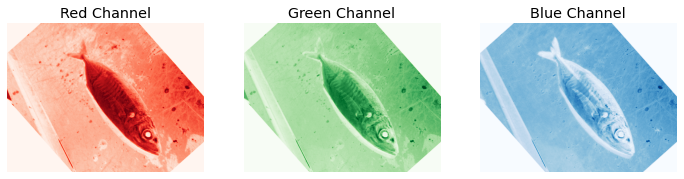

In [91]:
# Pick any real image from the loaded df for the RGB demo
sample_image = df['path'].iloc[0]
display_rgb_channels(sample_image)


### 2.3. Histogram of the each fish species images pixel distribution:

- As can be seen from the pixel distribution histogram graphs, each species has different color distributions

In [92]:
def plot_average_pixel_distribution_from_df(df: pd.DataFrame, target_size: tuple = (150, 150)) -> None:
    """
    Plots average pixel value distribution for each class based on a DataFrame containing image paths and labels.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'path' and 'label' columns.
    target_size (tuple): Size to which each image will be resized (default is (150, 150)).

    Returns:
    None: Displays the average pixel value histograms for each class.
    """
    
    unique_labels = df['label'].unique()
    plt.figure(figsize=(15, 10))
 
    for i, label in enumerate(unique_labels):
       
        class_images = df[df['label'] == label]['path'].values
        pixel_values = []
      
        for image_path in class_images:
            image = load_img(image_path, target_size=target_size)
            image_array = img_to_array(image) 
            pixel_values.append(image_array)
        
        pixel_values = np.array(pixel_values)
        avg_pixel_values = np.mean(pixel_values, axis=(0, 1, 2))  
       
        plt.subplot(3, 3, i + 1) 
        plt.hist(avg_pixel_values, bins=50, range=(0, 255), color='blue', alpha=0.7)
        plt.title(f'{label} Pixel Value Distribution')
        plt.xlabel('Pixel Value (0-255)')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

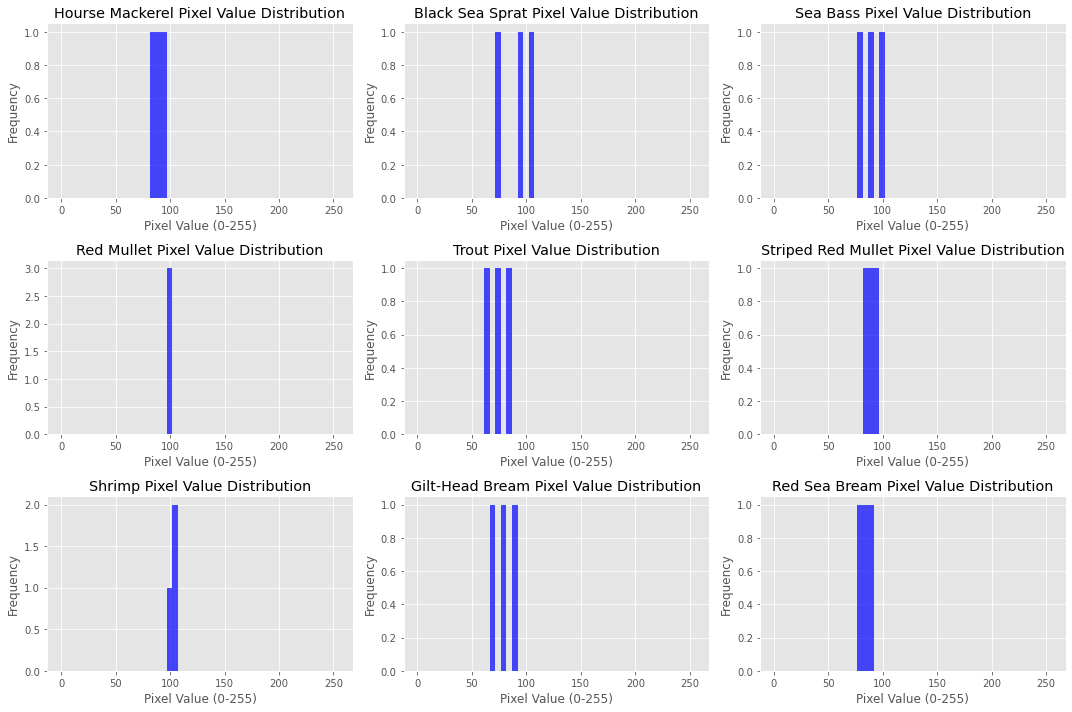

In [93]:
plot_average_pixel_distribution_from_df(df)

## 3. Image Preprocessing:

In [94]:
def load_image(image_path: str) -> Image.Image:
    """
    Load an image in RGB format from the given path.

    Parameters
    ----------
    image_path : str
        Path to the image file.

    Returns
    -------
    Image.Image
        Loaded image.
    """
    image = Image.open(image_path).convert("RGB")
    return image

def load_images_from_df(df: pd.DataFrame) -> List[Image.Image]:
    """
    Load images from a DataFrame containing image paths.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a column "path" for image file paths.

    Returns
    -------
    List[Image.Image]
        List of loaded images.
    """
    images = [load_image(image_path) for image_path in tqdm(df["path"].values.tolist(), total=len(df))]
    return images

In [114]:
loaded_images = load_images_from_df(df)

100%|██████████| 9000/9000 [01:52<00:00, 80.09it/s]


In [115]:
def plot_image(image: Image.Image) -> None:
    """
    Display an image using matplotlib with the axis turned off.
    
    Parameters
    ----------
    image : Image.Image
        The image to be displayed.
    
    Returns
    -------
    None
    """
    plt.imshow(image)
    plt.axis("off")
    plt.show()

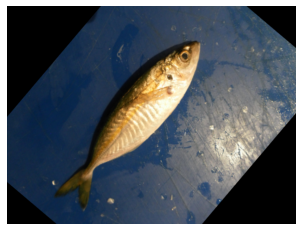

In [116]:
plot_image(loaded_images[20])

In [117]:
def preprocess(pil_image: Image.Image, square: bool = True) -> np.ndarray:
    """
    Advanced preprocessing pipeline:
    1. Center-crop to square (avoid stretching)
    2. Resize to 128x128 with LANCZOS
    3. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
       on the L channel in LAB space → improves contrast & detail
    4. Return as uint8 numpy array (normalisation done by ImageDataGenerator)
    """
    # 1. Center-crop to square
    if square:
        w, h = pil_image.size
        min_dim = min(w, h)
        left = (w - min_dim) // 2
        top  = (h - min_dim) // 2
        pil_image = pil_image.crop((left, top, left + min_dim, top + min_dim))

    # 2. Resize
    img = pil_image.resize((128, 128), Image.LANCZOS)
    img_np = np.array(img, dtype=np.uint8)

    # 3. CLAHE in LAB space
    lab = cv.cvtColor(img_np, cv.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv.split(lab)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l_channel)
    lab_eq = cv.merge([l_eq, a_channel, b_channel])
    img_out = cv.cvtColor(lab_eq, cv.COLOR_LAB2RGB)

    return img_out.astype(np.uint8)


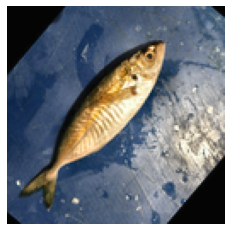

In [118]:
preprocessed_image = preprocess(loaded_images[20])
plot_image(preprocessed_image)

**Applying preprocessing to The All Images and Saving Them to Disk**

In [119]:
def process_and_save_images(df: pd.DataFrame, output_base_dir: str) -> None:
    """
    Load, process, and save images organized by labels into respective directories.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'path' and 'label' columns for images and their labels.
    output_base_dir : str
        The base directory where images will be saved, organized by labels.
    """
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing images"):
        label      = row['label']
        image_path = row['path']

        # Create per-class subdirectory
        label_dir = os.path.join(output_base_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        # Load → preprocess → save (keep original filename)
        img       = load_image(image_path)
        processed = preprocess(img)

        filename    = os.path.basename(image_path)
        output_file = os.path.join(label_dir, filename)
        Image.fromarray(processed).save(output_file)


In [120]:
# /kaggle/input is READ-ONLY → always write to /kaggle/working
output_path = '/kaggle/working/preprocessed_images'
os.makedirs(output_path, exist_ok=True)
print('Saving preprocessed images to:', output_path)


Saving preprocessed images to: /kaggle/working/preprocessed_images


In [121]:
process_and_save_images(df, output_path)

Processing images: 100%|██████████| 9000/9000 [03:07<00:00, 47.91it/s]


**Control**

- All processed images have been controlled using `df_from_image_folders` function that i created before

In [122]:
preprocessed_images = '/kaggle/working/preprocessed_images'
df_preprocessed = df_from_image_folders(preprocessed_images)
# Remove GT folders if any crept in
df_preprocessed = df_preprocessed[~df_preprocessed['label'].str.contains('GT', case=False)].reset_index(drop=True)
df_preprocessed.head()


,path,label
0,/kaggle/working/preprocessed_images/Gilt-Head Bream/00592.png,Gilt-Head Bream
1,/kaggle/working/preprocessed_images/Gilt-Head Bream/00175.png,Gilt-Head Bream
2,/kaggle/working/preprocessed_images/Gilt-Head Bream/00445.png,Gilt-Head Bream
3,/kaggle/working/preprocessed_images/Gilt-Head Bream/00782.png,Gilt-Head Bream
4,/kaggle/working/preprocessed_images/Gilt-Head Bream/00076.png,Gilt-Head Bream


In [123]:
df_preprocessed["label"].value_counts()

Gilt-Head Bream       1000
Striped Red Mullet    1000
Shrimp                1000
Red Sea Bream         1000
Trout                 1000
Black Sea Sprat       1000
Sea Bass              1000
Red Mullet            1000
Hourse Mackerel       1000
Name: label, dtype: int64

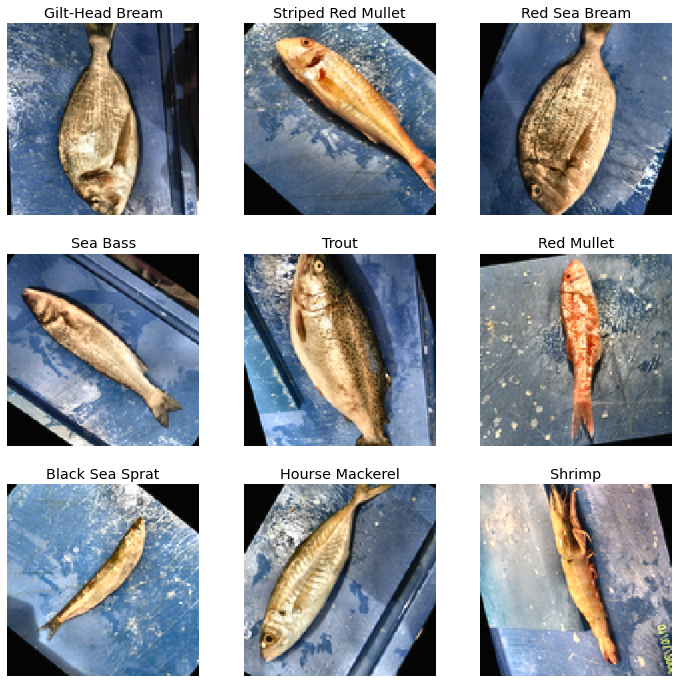

In [124]:
display_fish_from_each_class(df_preprocessed)

## 4. Neural Network (NN) Model Creation:

### 4.1. Splitting the Fish_Dataset into Train, Validation, and Test Sets.

10% of the dataset was allocated for validation and another 10% for testing. The validation set was used during model training, while the test set was reserved for evaluating the model's performance after training was completed.

In [125]:
def copy_images(subset_df: pd.DataFrame, target_dir: str) -> None:
    """
    Copies images from the DataFrame to the specified target directory.

    Parameters:
    - subset_df (pd.DataFrame): A DataFrame containing image paths in the 'path' column.
    - target_dir (str): The target directory where the images will be copied.

    Returns:
    - None: This function does not return any value.
    """
    for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc=f"Copying images to {target_dir}"):
        shutil.copy2(row['path'], target_dir)


def split_data_into_train_val_test(
    df_processed: pd.DataFrame, 
    output_dir: str, 
    train_ratio: float = 0.8, 
    val_ratio: float = 0.1, 
    test_ratio: float = 0.1,
    random_seed: int = 42 
) -> pd.DataFrame:
    """
    Splits dataset images into train, validation, and test sets based on fixed ratio for each class.

    Parameters:
    - df_processed (pd.DataFrame): DataFrame containing 'path' and 'label' columns for images.
    - output_dir (str): Directory where the train/validation/test folders will be created.
    - train_ratio (float): Proportion of data to allocate to the train set.
    - val_ratio (float): Proportion of data to allocate to the validation set.
    - test_ratio (float): Proportion of data to allocate to the test set.

    Returns:
    - pd.DataFrame: A DataFrame summarizing the counts of images in each set (train/val/test) per class.
    """
    
    np.random.seed(random_seed)
  
    df_processed = shuffle(df_processed).reset_index(drop=True)
    class_summary = {'Class': [], 'Train Count': [], 'Validation Count': [], 'Test Count': []}
    
   
    for class_name, class_group in df_processed.groupby('label'):
        
        total_images = len(class_group)
        train_count = int(total_images * train_ratio)
        val_count = int(total_images * val_ratio)
        test_count = total_images - train_count - val_count 

        class_summary['Class'].append(class_name)
        class_summary['Train Count'].append(train_count)
        class_summary['Validation Count'].append(val_count)
        class_summary['Test Count'].append(test_count)

        train_df = class_group[:train_count]
        val_df = class_group[train_count:train_count + val_count]
        test_df = class_group[train_count + val_count:]
        
        train_dir = os.path.join(output_dir, 'train', class_name)
        val_dir = os.path.join(output_dir, 'validation', class_name)
        test_dir = os.path.join(output_dir, 'test', class_name)
        
        for dir_path in [train_dir, val_dir, test_dir]:
            if not os.path.exists(dir_path):
                os.makedirs(dir_path)
        
        copy_images(train_df, train_dir)
        copy_images(val_df, val_dir)
        copy_images(test_df, test_dir)
    
    summary_df = pd.DataFrame(class_summary)
    
    return summary_df

In [126]:
model_images_output = '/kaggle/working/model_dataset'
summary_df = split_data_into_train_val_test(df_preprocessed, model_images_output)
summary_df


Copying images to /kaggle/working/model_dataset/train/Black Sea Sprat: 100%|██████████| 800/800 [00:00<00:00, 2772.26it/s]
Copying images to /kaggle/working/model_dataset/validation/Black Sea Sprat: 100%|██████████| 100/100 [00:00<00:00, 2649.98it/s]
Copying images to /kaggle/working/model_dataset/test/Black Sea Sprat: 100%|██████████| 100/100 [00:00<00:00, 2364.65it/s]
Copying images to /kaggle/working/model_dataset/train/Gilt-Head Bream: 100%|██████████| 800/800 [00:00<00:00, 2624.37it/s]
Copying images to /kaggle/working/model_dataset/validation/Gilt-Head Bream: 100%|██████████| 100/100 [00:00<00:00, 2639.94it/s]
Copying images to /kaggle/working/model_dataset/test/Gilt-Head Bream: 100%|██████████| 100/100 [00:00<00:00, 2609.24it/s]
Copying images to /kaggle/working/model_dataset/train/Hourse Mackerel: 100%|██████████| 800/800 [00:00<00:00, 2608.87it/s]
Copying images to /kaggle/working/model_dataset/validation/Hourse Mackerel: 100%|██████████| 100/100 [00:00<00:00, 2397.75it/s]
Cop

,Class,Train Count,Validation Count,Test Count
0,Black Sea Sprat,800,100,100
1,Gilt-Head Bream,800,100,100
2,Hourse Mackerel,800,100,100
3,Red Mullet,800,100,100
4,Red Sea Bream,800,100,100
5,Sea Bass,800,100,100
6,Shrimp,800,100,100
7,Striped Red Mullet,800,100,100
8,Trout,800,100,100


In [127]:
gc.collect()


29284

### 4.2. Data Augmentation

As previously mentioned, data augmentation was performed on the dataset used in this study. However, it is assumed that these operations were not carried out before.

**Data Augmentation Steps:**

- `Normalization`: Rescaling pixel values from the range of 0-255 to 0-1.
- `Random Rotation`: Rotating images up to 40 degrees randomly.
- `Random Width and Height Shift`: Shifting images randomly by 20% of their width and height.
- `Random Shear`: Applying random shearing transformations with a shear intensity of 0.2.
- `Random Zoom`: Zooming in on images randomly by 20%.
- `Horizontal Flip`: Flipping images horizontally.
- `Fill Method`: Using the 'nearest' fill mode for newly created pixels during transformations.

In [128]:
train_dir      = '/kaggle/working/model_dataset/train'
validation_dir = '/kaggle/working/model_dataset/validation'


In [129]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    fill_mode='nearest',
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',   # 9 classes → categorical, NOT binary
    color_mode='rgb',
    shuffle=True,
)
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)
class_indices = train_generator.class_indices
print('Class labels:', class_indices)


Found 7200 images belonging to 9 classes.
Found 900 images belonging to 9 classes.
Class labels: {'Black Sea Sprat': 0, 'Gilt-Head Bream': 1, 'Hourse Mackerel': 2, 'Red Mullet': 3, 'Red Sea Bream': 4, 'Sea Bass': 5, 'Shrimp': 6, 'Striped Red Mullet': 7, 'Trout': 8}


**Data augmentation Control**

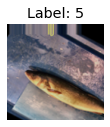

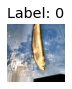

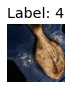

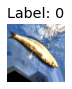

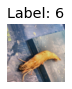

In [130]:
import numpy as np
batch = next(train_generator)
images, labels = batch
num_images = min(5, len(images))

plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i]) 
    plt.title(f"Label: {np.argmax(labels[i])}")
    plt.axis('off') 
    plt.show()

### 4.3. Creation of the ANN Architecture

**The following operations have been performed:**

1. **Data Augmentation**

     Data augmentation can be applied for this model.

2. **Techniques Implemented to Prevent Overfitting**

    Train and validation datasets used to train the DNN model. Dropout and batch normalization are applied to prevent overfitting.
  
    `Dropout` is a regularization technique used in neural networks that randomly sets a fraction of the neurons to zero during training, helping to prevent overfitting by ensuring the model does not become too reliant on any single feature.
  
    `Batch normalization` normalizes the inputs of each layer in the neural network by adjusting and scaling the activations, which accelerates training, reduces sensitivity to initialization and helps mitigate overfitting by providing some regularization effect.
  
3. **Early stopping, Learning rate decay and checkpoint callbacks.**
  
   - To avoid prolonging the training duration, an `early stopping callback` can be used. Training will be terminated if no improvement is observed after 6 epochs

   - A `checkpoint callback` can be implemented to save the best model. The checkpoint callback monitored and saved the model with the lowest validation loss. To save  space, models were not saved separately but overwritten instead.

   - `The learning rate decay callback (ReduceLROnPlateau)` helps the model continue learning by reducing the learning rate if there is no improvement after 4 epochs.
  
4. **Determining the necessary hyperparameters.**
       
    ```
        - Number of Layers: 
        - Number of Neurons: 
        - Batch size: 
        - Activation Function: 
        - Optimization Algorithm: 
        - Learning Rate: 
        - Image size: 128 x 128   ```
 
5. **Selecting Performance Metric**

    Since all classes in the dataset are evenly distributed, accuracy can been chosen as the metric during training. `Accuracy` generally indicates how well the model makes predictions.


$$
\text{Accuracy} = \frac{TP + TN}{TP + FP + FN + TN}
$$

    True Positive (TP): Correctly predicted positive instances.
    True Negative (TN): Correctly predicted negative instances.
    False Positive (FP): Incorrectly predicted positive instances.
    False Negative (FN): Incorrectly predicted negative instance

### Improvements applied in this version

| # | What | Why |
|---|------|-----|
| 1 | **CLAHE preprocessing** | Enhances contrast in low-contrast underwater fish images before training |
| 2 | **4 hidden layers** (1024→512→256→128) with **LeakyReLU** | Deeper pyramid avoids dying-ReLU problem, learns richer features |
| 3 | **Richer augmentation** (brightness + channel shift) | Makes the model robust to lighting variations |
| 4 | **Adam lr=0.001** with `weight_decay=1e-4` | Correct starting LR (0.01 was too high); weight decay adds L2 regularisation |
| 5 | **`batch_size=32`** | Larger batch → more stable gradient estimates |
| 6 | **EarlyStopping patience=20** | Gives model time to escape plateaus instead of stopping too early |
| 7 | **ReduceLROnPlateau patience=8, factor=0.4** | More gradual LR schedule |
| 8 | **`restore_best_weights=True`** | After early stopping, model weights revert to the best epoch automatically |
| 9 | **Improved loss/accuracy plot** | Shows best epoch line + summary statistics |


In [ ]:
from tensorflow.keras.utils import 4register_keras_serializable
class CustomDNN(Model):
    def __init__(self, input_shape=(128, 128, 3), num_classes=9, name="custom_dnn", **kwargs):
        super(CustomDNN, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self._input_shape_cfg = input_shape

        self.flatten = Flatten()

        # --- Layer 1: 1024 units ---
        self.dense1 = Dense(1024, dtype='float32') #1024 units for more capacity to learn complex patterns in the data
        self.bn1    = BatchNormalization() #instead of leting data randomly, they are centered
        self.act1 = LeakyReLU(alpha=0.1)   #activation function , neg * 0.1 : allows small gradients for negative inputs, helps with "dying ReLU" problem
        self.drop1  = Dropout(0.4) #reduce overfitting by randomly turning off 40% of the neurons during training

        # --- Layer 2: 512 units ---
        self.dense2 = Dense(512, dtype='float32')
        self.bn2    = BatchNormalization()
        self.act2   = LeakyReLU(alpha=0.1)
        self.drop2  = Dropout(0.35)

        # --- Layer 3: 256 units ---
        self.dense3 = Dense(256, dtype='float32')
        self.bn3    = BatchNormalization()
        self.act3   = LeakyReLU(alpha=0.1)
        self.drop3  = Dropout(0.3)

        # --- Layer 4: 128 units ---
        self.dense4 = Dense(128, dtype='float32')
        self.bn4    = BatchNormalization()
        self.act4   = LeakyReLU(alpha=0.1)
        self.drop4  = Dropout(0.2)

        self.classifier = Dense(num_classes, activation='softmax', dtype='float32') # final layer with softmax for multi-class classification

    def call(self, inputs, training=False): # forward pass
        x = self.flatten(inputs)

        x = self.dense1(x)
        x = self.bn1(x, training=training)
        x = self.act1(x)
        x = self.drop1(x, training=training)

        x = self.dense2(x)
        x = self.bn2(x, training=training)
        x = self.act2(x)
        x = self.drop2(x, training=training)

        x = self.dense3(x)
        x = self.bn3(x, training=training)
        x = self.act3(x)
        x = self.drop3(x, training=training)

        x = self.dense4(x)
        x = self.bn4(x, training=training)
        x = self.act4(x)
        x = self.drop4(x, training=training)

        return self.classifier(x)

    def get_config(self):
        config = super(CustomDNN, self).get_config()
        config.update({'input_shape': self._input_shape_cfg, 'num_classes': self.num_classes})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def train(self, train_dir, val_dir, batch_size=32, epochs=200): # train method to handle data loading, augmentation, callbacks, and training
        # ── Augmentation (richer than before)
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=30,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.15,
            zoom_range=0.2,
            horizontal_flip=True,
            brightness_range=[0.75, 1.25],
            channel_shift_range=20.0,
            fill_mode='nearest',
        )
        val_datagen = ImageDataGenerator(rescale=1./255)

        target_size = self._input_shape_cfg[:2]

        train_generator = train_datagen.flow_from_directory(
            train_dir, target_size=target_size, batch_size=batch_size,
            class_mode='categorical', color_mode='rgb', shuffle=True,
        )
        validation_generator = val_datagen.flow_from_directory(
            val_dir, target_size=target_size, batch_size=batch_size,
            class_mode='categorical', color_mode='rgb', shuffle=False,
        )

        # ── Callbacks ──────────────────────────────────────────────────────
        os.makedirs('/kaggle/working/models', exist_ok=True)
        checkpoint = ModelCheckpoint(
            filepath='/kaggle/working/models/best_model.keras',
            monitor='val_loss', save_best_only=True, mode='min', verbose=1
        )
        # patience=20 so model gets enough time to improve before stopping
        early_stop = EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
        )
        # Reduce LR when plateau detected (patience=8)
        lr_reduce = ReduceLROnPlateau(
            monitor='val_loss', factor=0.4, patience=8,
            min_lr=1e-6, verbose=1
        )

        # ── Optimizer: Adam with momentum (beta_1) + weight decay 
        # Adam already uses momentum (beta_1=0.9). We start with lr=0.001
        # which is the standard recommended value (not 0.01 which is too high).
        optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
        self.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = self.fit(
            train_generator,
            epochs=epochs,
            validation_data=validation_generator,
            callbacks=[checkpoint, early_stop, lr_reduce],
        )
        return history


In [ ]:
train_dir = '/kaggle/working/model_dataset/train'
val_dir   = '/kaggle/working/model_dataset/validation'

model = CustomDNN(input_shape=(128, 128, 3), num_classes=9)
result = model.train(train_dir=train_dir, val_dir=val_dir, batch_size=32, epochs=200)


Found 7200 images belonging to 9 classes.
Found 900 images belonging to 9 classes.
Epoch 1/200
225/225 [==============================] - 73s 315ms/step - loss: 2.2851 - accuracy: 0.1838 - val_loss: 1.8374 - val_accuracy: 0.2956

Epoch 00001: val_loss improved from inf to 1.83742, saving model to /kaggle/working/models/best_model.keras
Epoch 2/200
225/225 [==============================] - 71s 313ms/step - loss: 1.8667 - accuracy: 0.2819 - val_loss: 2.6867 - val_accuracy: 0.1500

Epoch 00002: val_loss did not improve from 1.83742
Epoch 3/200
225/225 [==============================] - 70s 312ms/step - loss: 1.7380 - accuracy: 0.3550 - val_loss: 1.5556 - val_accuracy: 0.4233

Epoch 00003: val_loss improved from 1.83742 to 1.55560, saving model to /kaggle/working/models/best_model.keras
Epoch 4/200
225/225 [==============================] - 71s 316ms/step - loss: 1.6753 - accuracy: 0.3645 - val_loss: 2.4619 - val_accuracy: 0.2333

Epoch 00004: val_loss did not improve from 1.55560
Epoch 5

In [ ]:
model = load_model('/kaggle/working/models/best_model.keras')
model.summary()


**Visualize with History**

In [ ]:
def plot_training_history(result) -> None:
    """
    Plots training/validation loss AND accuracy.
    Also marks the epoch where best val_loss was reached.
    """
    history = result.history if hasattr(result, 'history') else result

    epochs_range = range(1, len(history['loss']) + 1)
    best_epoch   = int(np.argmin(history['val_loss'])) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History', fontsize=14, fontweight='bold')

    # ── Loss graph ─────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs_range, history['loss'],     label='Train Loss',      color='steelblue')
    ax.plot(epochs_range, history['val_loss'], label='Validation Loss', color='tomato')
    ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.2,
               label=f'Best epoch ({best_epoch})')
    ax.set_title('Loss (↓ = model is learning)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Categorical Cross-Entropy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Accuracy graph ─────────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.plot(epochs_range, history['accuracy'],     label='Train Accuracy',      color='steelblue')
    ax2.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='tomato')
    ax2.axvline(best_epoch, color='green', linestyle='--', linewidth=1.2,
                label=f'Best epoch ({best_epoch})')
    ax2.set_title('Accuracy (↑ = model is improving)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────────
    best_val_loss = min(history['val_loss'])
    best_val_acc  = history['val_accuracy'][np.argmin(history['val_loss'])]
    print(f'\n📊 Training summary:')
    print(f'  • Total epochs run   : {len(history["loss"])}')
    print(f'  • Best epoch         : {best_epoch}')
    print(f'  • Best val_loss      : {best_val_loss:.4f}')
    print(f'  • Val accuracy @ best: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')


In [ ]:
plot_training_history(history)

### 4.4. Model Evaluation

The following tasks have been carried out:

- After training is completed, the model's performance is evaluated on the test set.
  
- The performance of the model is analyzed using metrics such as classification accuracy, confusion matrix, accuracy, precision, and recall.
  
- Errors are examined by visualizing the examples that the model misclassified.

**After the test data is formatted appropriately and predictions are made, the performance metrics have been calculated.**



**Evaluation Metrics**

**Precision:**

- **Definition:** The ratio of true positive predictions to all positive predictions (true positives + false positives).
- **Formula:**
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$

**Recall:**

- **Definition:** The ratio of true positives to all positive cases (true positives + false negatives).
- **Formula:**
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$

**Accuracy:**

- **Definition:** The ratio of correct predictions to the total predictions.
- **Formula:**
  $$
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$


**Confusion Matrix and Classification Report Insights:**

**Overall Metrics:**

`Accuracy:`  - The model correctly classified images across all classes.

`Macro Average Precision:`  - Average precision across all classes, not considering class imbalance.

`Macro Average Recall:`  - Average recall across all classes.

---

**Class-Level Insights:**

- `Class 0 (Black Sea Sprat):` 
  
- `Class 1 (Gilt-Head Bream):` 

- `Class 2 (Horse Mackerel):` 

- `Class 3 (Red Mullet):` 

- `Class 4 (Red Sea Bream):` 

- `Class 5 (Sea Bass):` 

- `Class 6 (Shrimp):` 

- `Class 7 (Striped Red Mullet):` 

- `Class 8 (Trout):` 

---

**Conclusion:**



In [ ]:
def evaluate_model(
    model, 
    test_dir: str, 
    target_size: tuple = (128, 128), 
    batch_size: int = 32
) -> None:
    """
    Evaluate the model on the test dataset and display performance metrics.

    Parameters:
    model: The trained model to evaluate.
    test_dir (str): Directory path to the test dataset.
    target_size (tuple): Target size for the input images (height, width).
    batch_size (int): Number of images to process in each batch.

    Returns:
    None: This function prints the accuracy, precision, recall, and displays
          confusion matrix and classification report.
    """

 
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical', 
        shuffle=False
    )

    predictions = model.predict(test_generator)

    predicted_classes = np.argmax(predictions, axis=1)

    true_classes = test_generator.classes

    # Performance Metrics
    accuracy = accuracy_score(true_classes, predicted_classes)
    precision = precision_score(true_classes, predicted_classes, average='macro')  
    recall = recall_score(true_classes, predicted_classes, average='macro') 

    print("Accuracy:", accuracy)
    print("Precision (macro):", precision)
    print("Recall (macro):", recall)

    # Confusion Matrix
    conf_matrix = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # Classification Report
    print(classification_report(true_classes, predicted_classes))
    
    return test_generator ,predicted_classes


In [ ]:
test_directory = '/kaggle/working/model_dataset/test'
test_generator, predicted_classes = evaluate_model(model, test_directory)


**Analyze Misclassifications**

In [ ]:
def analyze_and_visualize_misclassifications(test_generator, predicted_classes, num_samples=10) -> None:
    """
    Analyze and visualize misclassified images from the test dataset.

    Parameters:
    test_generator: The generator used to load the test data.
    predicted_classes: The predicted class indices from the model.
    num_samples: The number of misclassified images to display.

    Returns:
    None: This function prints the total number of misclassified images and shows a plot of some misclassified examples.
    """
    
    test_generator.reset()

    df = pd.DataFrame({
        'filename': test_generator.filenames,
        'predict': predicted_classes,  
        'y': test_generator.classes
    })
    misclassified = df[df['y'] != df['predict']]
    total_misclassified = misclassified.shape[0]
    
    print(f'Total misclassified images: {total_misclassified}')
    print("\nMisclassified Images:")
    print(misclassified)

    if total_misclassified > 0:
   
        samples_to_display = min(num_samples, total_misclassified)
        misclassified_samples = misclassified.sample(samples_to_display)
        
        cols = 5
        rows = (samples_to_display + cols - 1) // cols 
        fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
        
        for ax, (_, row) in zip(axes.flatten(), misclassified_samples.iterrows()):
            img_path = test_generator.directory + '/' + row['filename']
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.set_title(f'True: {row["y"]}, Pred: {row["predict"]}')
            ax.axis('off')

        for i in range(samples_to_display, len(axes.flatten())):
            axes.flatten()[i].axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
analyze_and_visualize_misclassifications(test_generator, predicted_classes, num_samples=10)

### 4.5. **Prediction**

A random image for each fish in the test folder has been selected and compiled into a list and it was observed that the model successfully made accurate predictions for fish species.

In [ ]:
def predict_single_image(model, image_path, test_generator):
    """
    Predict the class of a single image using a trained model.

    Parameters:
    model: The trained Keras model for image classification.
    image_path: Path to the image to be classified.
    test_generator: Keras ImageDataGenerator flow generator.

    Returns:
    None: This function displays the image and prints the predicted class with confidence.
    """
    image = load_img(image_path, target_size=(128, 128))
    plt.imshow(image)
    plt.title(f"Selected Image: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()
   
    image_array = img_to_array(image) / 255.0 
    image_array = np.expand_dims(image_array, axis=0)  

    predictions = model.predict(image_array)
    predicted_index = np.argmax(predictions, axis=1)[0] 

    class_indices = test_generator.class_indices
    class_labels = {v: k for k, v in class_indices.items()} 

    predicted_label = class_labels[predicted_index]
    confidence = predictions[0][predicted_index]

    print(f"Predicted Label: {predicted_label} (Confidence: {confidence:.2f})")


**Prediction list for each class from the test image directory**

In [ ]:
test_folder = '/kaggle/working/model_dataset/test'
test_df = df_from_image_folders(test_folder)
# Remove GT folders
test_df = test_df[~test_df['label'].str.contains('GT', case=False)].reset_index(drop=True)
prediction_list = test_df.groupby('label')['path'].sample(1).to_list()


In [ ]:
for image in prediction_list:
    class_name = os.path.basename(os.path.dirname(image))
    predict_single_image(model, image, test_generator)
    print(f"Actual label: {class_name}")
    print(50 * " ")
    print(50 * "*")